# Investigating C Cases Matched to Multiple R Cases

In the RC → CA matching pipeline (`match_r_to_c_cases.py`), a single **C Case (CA charge)** can end up linked to **several R Cases (RC petitions)**. This notebook quantifies and characterises that situation so we can decide how to interpret it.

**Why a C Case might legitimately map to multiple R Cases**
- Different bargaining **units inside the same establishment** each filed an RC petition, and the same employer ULP charge (CA) touches all of them.
- **Several distinct establishments** of the same firm — possibly in different cities — were affected by the same conduct.

**Why it might be a matching error**
- We matched on *company name + city + date window* (within an NLRB Region). The same CA charge can be mistakenly attached to **two different branches of the firm in the same city**, even though only one branch is genuinely involved.
- Fuzzy / cluster name collapsing can merge firms that are not actually the same entity.

**Discriminator used below — Zip code.** Used as a *soft* signal for telling branches apart within a city. **Caveat:** the zip data has a known city/zip time mismatch, concentrated in the **NxGen period (CA filed 2011 onward)**, so it was deliberately *not* used in matching. We flag NxGen-era CA cases so zip-based judgments can be down-weighted there.

> **Note on NLRB Region.** Region consistency — RC and CA filed in the same Regional Office (the leading two digits of the case number, e.g. `07-CA-…` → Region 07) — is now **enforced upstream in `match_r_to_c_cases.py`** as an equi-key, alongside company / state / city. Every pair in these match files is therefore already same-Region, so the cross-region analysis that previously lived in this notebook has been removed.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 40)

# This notebook lives in multi_r_per_c_investigation/; inputs live in the project root.
# Outputs (multi_r_per_c_*, multi_r_zip_resolvable_*) are written alongside this notebook.
DATA_DIR = Path("..")
OUT_DIR = Path(".")

# The two matching outputs we want to compare. Add / remove as needed.
MATCH_FILES = {
    "fuzzy":   DATA_DIR / "rc_ac_matches.parquet",
    "cluster": DATA_DIR / "rc_ac_cluster_matches_20260517.parquet",
}

# Address tables — used to pull zip_code (soft branch discriminator).
R_ADDR_FILE = DATA_DIR / "merged_R_CASES_ADDRESS_with_union_flag.parquet"
C_ADDR_FILE = DATA_DIR / "merged_C_CASES_ADDRESS_with_union_flag.parquet"

# Start of the NxGen filing system. Zip codes are unreliable from here on
# (city/zip time mismatch), so zip-based judgements are flagged as soft.
NXGEN_START = pd.Timestamp("2011-01-01")

In [2]:
# ---- Load the match outputs ----
matches = {}
for name, path in MATCH_FILES.items():
    if path.exists():
        df = pd.read_parquet(path)
        matches[name] = df
        print(f"{name:>8s}: {len(df):>8,} pairs  |  "
              f"{df['r_case_number'].nunique():>7,} RC  |  "
              f"{df['c_case_number'].nunique():>7,} CA  |  {path.name}")
    else:
        print(f"{name:>8s}: FILE NOT FOUND — {path}")

assert matches, "No match files loaded — check MATCH_FILES paths."

   fuzzy:   50,472 pairs  |   25,867 RC  |   46,573 CA  |  rc_ac_matches.parquet
 cluster:   60,731 pairs  |   29,554 RC  |   55,611 CA  |  rc_ac_cluster_matches_20260517.parquet


In [ ]:
# ---- Enrich each match table with zip and NxGen-era flag ----
r_addr = pd.read_parquet(R_ADDR_FILE).rename(columns={"case_number": "r_case_number"})
c_addr = pd.read_parquet(C_ADDR_FILE).rename(columns={"case_number": "c_case_number"})

r_zip = (r_addr.drop_duplicates("r_case_number")
               .set_index("r_case_number")["zip_code"].rename("r_zip"))
c_zip = (c_addr.drop_duplicates("c_case_number")
               .set_index("c_case_number")["zip_code"].rename("c_zip"))

def enrich(df):
    out = df.copy()
    out["r_zip"] = out["r_case_number"].map(r_zip)
    out["c_zip"] = out["c_case_number"].map(c_zip)
    out["c_nxgen"] = pd.to_datetime(out["c_date_filed"], errors="coerce") >= NXGEN_START
    return out

matches = {name: enrich(df) for name, df in matches.items()}
print("Added r_zip / c_zip / c_nxgen.")

## 1. How many C Cases are matched to multiple R Cases?

For each method we compute, for every CA case, the number of distinct RC cases it is matched to (`rc_per_ca`), then report how many CA cases exceed one.

In [4]:
def rc_per_ca(df):
    """Series: c_case_number -> number of distinct RC cases matched."""
    return df.groupby("c_case_number")["r_case_number"].nunique()

summary_rows = []
for name, df in matches.items():
    counts = rc_per_ca(df)
    n_ca = len(counts)
    n_multi = int((counts > 1).sum())
    n_excess_pairs = int((counts[counts > 1] - 1).sum())  # extra links beyond the first
    summary_rows.append({
        "method": name,
        "total_pairs": len(df),
        "CA cases (matched)": n_ca,
        "CA matched to >1 RC": n_multi,
        "% CA matched to >1 RC": round(100 * n_multi / n_ca, 1),
        "max RC per CA": int(counts.max()),
        "excess RC links": n_excess_pairs,
    })

summary = pd.DataFrame(summary_rows).set_index("method")
summary

,total_pairs,CA cases (matched),CA matched to >1 RC,% CA matched to >1 RC,max RC per CA,excess RC links
method,,,,,,
fuzzy,50472,46573,2609,5.6,17,3899
cluster,60731,55611,3496,6.3,17,5120


## 2. Distribution of R Cases per C Case

How heavy is the tail? A few CA cases matched to many RC cases are the most suspicious.

In [5]:
dist_frames = []
for name, df in matches.items():
    counts = rc_per_ca(df)
    vc = counts.value_counts().sort_index()
    bucketed = vc[vc.index <= 5].copy()
    tail = int(vc[vc.index >= 6].sum())
    bucketed.index = bucketed.index.astype(str)
    if tail:
        bucketed["6+"] = tail
    dist_frames.append(bucketed.rename(name))

dist = pd.concat(dist_frames, axis=1).fillna(0).astype(int)
dist.index.name = "RC per CA"
print("Number of CA cases by how many RC cases they match:")
dist

Number of CA cases by how many RC cases they match:


,fuzzy,cluster
RC per CA,,
1,43964,52115
2,2005,2702
3,372,477
4,97,164
5,31,40
6+,104,113


In [6]:
qs = [0.5, 0.9, 0.95, 0.99, 1.0]
quant = pd.DataFrame({name: rc_per_ca(df).quantile(qs) for name, df in matches.items()})
quant.index = [f"p{int(q*100)}" for q in qs]
quant

,fuzzy,cluster
p50,1.0,1.0
p90,1.0,1.0
p95,2.0,2.0
p99,3.0,3.0
p100,17.0,17.0


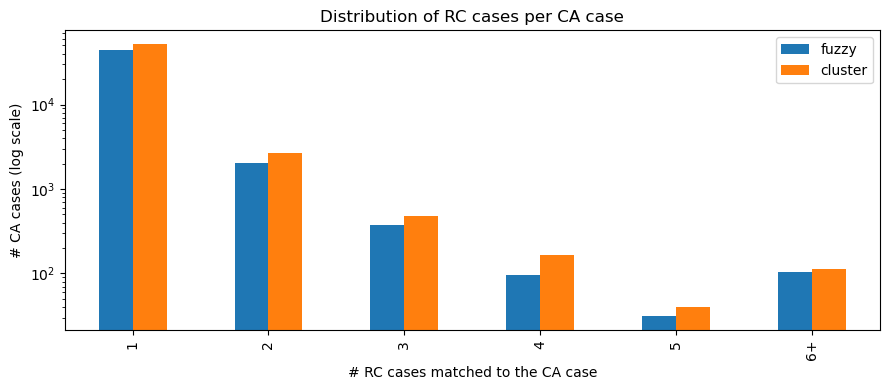

In [7]:
try:
    import matplotlib.pyplot as plt
    ax = dist.plot(kind="bar", figsize=(9, 4))
    ax.set_yscale("log")
    ax.set_ylabel("# CA cases (log scale)")
    ax.set_xlabel("# RC cases matched to the CA case")
    ax.set_title("Distribution of RC cases per CA case")
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f"(skipping plot: {e})")

## 3. Characterising the multi-R groups

For each CA matched to >1 RC, we describe the set of RC cases it links to and assign a **`geo_pattern`** — the geographic shape using city and (soft) zip:

- *different cities* — RC cases span different cities (genuine multi-establishment, or name over-merge).
- *same city, diff zip* — same city, different zips: plausibly different **branches** (the flagged error risk). **Soft when NxGen.**
- *same city, same/blank zip* — same place: different units, or duplicate links.

`ca_nxgen` marks groups where the zip signal is unreliable, so a *same city, diff zip* label there should not be trusted on its own.

In [ ]:
def _norm(s):
    return (s.fillna("").astype(str).str.lower().str.strip()
             .str.replace(r"[.,'\"]", "", regex=True)
             .str.replace(r"\s+", " ", regex=True))

def _norm_zip(s):
    z = s.fillna("").astype(str).str.extract(r"(\d{5})", expand=False)
    return z.fillna("")

def profile_multi(df):
    """One row per CA case matched to >1 RC, describing its RC set."""
    d = df.copy()
    d["_rcity"] = _norm(d["r_city"])
    d["_rcomp"] = _norm(d.get("match_company_r", d["r_company_name"]))
    d["_rzip"] = _norm_zip(d["r_zip"])
    d["r_date_filed"] = pd.to_datetime(d["r_date_filed"], errors="coerce")

    counts = d.groupby("c_case_number")["r_case_number"].nunique()
    d = d[d["c_case_number"].isin(counts[counts > 1].index)]

    g = d.groupby("c_case_number")
    prof = pd.DataFrame({
        "n_rc": g["r_case_number"].nunique(),
        "n_rc_cities": g["_rcity"].nunique(),
        "n_rc_companies": g["_rcomp"].nunique(),
        "n_rc_zips": g["_rzip"].apply(lambda s: s[s != ""].nunique()),
        "ca_nxgen": g["c_nxgen"].first(),
        "rc_span_days": (g["r_date_filed"].max() - g["r_date_filed"].min()).dt.days,
        "c_company": g["c_company_name"].first(),
        "c_city": g["c_city"].first(),
    })
    if "match_method" in d.columns:
        prof["methods"] = g["match_method"].apply(lambda s: ",".join(sorted(set(s))))

    # ---- geographic pattern (zip is soft, esp. NxGen) ----
    def geo(r):
        if r["n_rc_cities"] > 1:
            return "different cities"
        if r["n_rc_zips"] > 1:
            return "same city, diff zip"
        return "same city, same/blank zip"
    prof["geo_pattern"] = prof.apply(geo, axis=1)
    return prof.sort_values(["geo_pattern", "n_rc"], ascending=[True, False])

profiles = {name: profile_multi(df) for name, df in matches.items()}
for name, prof in profiles.items():
    print(f"=== {name}: {len(prof):,} CA cases matched to >1 RC ===")
    print("geo_pattern:")
    print(prof["geo_pattern"].value_counts().to_string())
    print()

In [11]:
# How much of the 'same city, diff zip' signal is trustworthy?
# Break the diff-zip groups down by era (zip is unreliable for NxGen-era CA cases).
for name, prof in profiles.items():
    dz = prof[prof["geo_pattern"] == "same city, diff zip"]
    if dz.empty:
        continue
    n_nxgen = int(dz["ca_nxgen"].sum())
    print(f"{name}: 'same city, diff zip' groups = {len(dz):,}  |  "
          f"NxGen (zip unreliable) = {n_nxgen:,} ({100*n_nxgen/len(dz):.1f}%)  |  "
          f"pre-NxGen (zip usable) = {len(dz)-n_nxgen:,}")

fuzzy: 'same city, diff zip' groups = 437  |  NxGen (zip unreliable) = 137 (31.4%)  |  pre-NxGen (zip usable) = 300
cluster: 'same city, diff zip' groups = 573  |  NxGen (zip unreliable) = 166 (29.0%)  |  pre-NxGen (zip usable) = 407


## 4. Breakdown by match method (within a single output)

Are the multi-R links coming from the exact pass or the fuzzy pass? Fuzzy-driven duplicates are more suspect. (Only meaningful for the hybrid `fuzzy` output, which carries both `exact` and `fuzzy` in `match_method`.)

In [12]:
for name, df in matches.items():
    if "match_method" not in df.columns or df["match_method"].nunique() < 2:
        continue
    counts = rc_per_ca(df)
    sub = df[df["c_case_number"].isin(counts[counts > 1].index)]
    print(f"=== {name}: match_method of links involved in multi-R CA cases ===")
    print(sub["match_method"].value_counts().to_string())
    has_fuzzy = sub.groupby("c_case_number")["match_method"].apply(lambda s: (s == "fuzzy").any())
    print(f"Multi-R CA groups containing >=1 fuzzy link: "
          f"{int(has_fuzzy.sum()):,} / {len(has_fuzzy):,} ({100*has_fuzzy.mean():.1f}%)")
    print()

=== fuzzy: match_method of links involved in multi-R CA cases ===
match_method
exact    5124
fuzzy    1384
Multi-R CA groups containing >=1 fuzzy link: 744 / 2,609 (28.5%)



## 5. Inspect concrete examples

Pull the full set of RC links for sampled multi-R CA cases, so you can eyeball whether they look genuine or spurious. Era columns are shown alongside city/zip.

In [ ]:
DISPLAY_COLS = [
    "c_case_number", "r_case_number", "match_method",
    "c_nxgen",
    "c_company_name", "r_company_name",
    "c_city", "r_city", "c_zip", "r_zip",
    "c_date_filed", "r_date_filed", "r_date_closed", "fuzzy_score",
]

def show_examples(method, geo_pattern=None, n=3, seed=0):
    df = matches[method]
    prof = profiles[method]
    cand = prof
    if geo_pattern is not None:
        cand = cand[cand["geo_pattern"] == geo_pattern]
    if cand.empty:
        print(f"No groups matching geo_pattern={geo_pattern!r} in {method}.")
        return
    pick = cand.sample(min(n, len(cand)), random_state=seed).index
    cols = [c for c in DISPLAY_COLS if c in df.columns]
    for ca in pick:
        block = df[df["c_case_number"] == ca][cols].sort_values("r_date_filed")
        print(f"\n--- {method} | geo={geo_pattern} | CA={ca} "
              f"({len(block)} RC links) ---")
        display(block)

# A general sample of multi-R groups to eyeball (any geo pattern)
show_examples("fuzzy", n=4)

In [ ]:
# The flagged 'branch' risk: same city, different zip
show_examples("fuzzy", geo_pattern="same city, diff zip", n=3)

In [ ]:
# Different cities — candidate genuine multi-establishment ULPs
show_examples("fuzzy", geo_pattern="different cities", n=3)

## 6. Does reliable ZIP help resolve the multi-R groups?

Now that every case carries a validated `zip_reliable` flag (from `validate_zip_city_state.ipynb`), we bring it into the multi-R groups and ask three things:

1. **Coverage** — are there *enough* reliable ZIPs for the test to apply at all? To compare branches we need ≥2 R cases with reliable ZIPs; to adjudicate we also need a reliable C ZIP.
2. **Characterize** — of the raw `same city, diff zip` branch signals (Section 3), how many *survive* when we keep only reliable ZIPs? The rest were ZIP-data artifacts (HQ/garbage/retired ZIPs), not real different-branch evidence.
3. **Resolve** — where the C case has a reliable ZIP, can it pick the *correct* branch among the R cases (keep the matching one, flag the others as different-branch)? This is the use that would actually fix over-linking.

ZIP is the *same-city* branch discriminator (cross-region links are already removed upstream by the matching pipeline). Reliability gating uses the unified flag (NxGen source flag / CHIPS–CATS GeoNames).

In [ ]:
# ---- Attach the unified ZIP-reliability flag (from validate_zip_city_state.ipynb) ----
# The validation CSVs now live in ../zip_validation/ (DATA_DIR is the project root).
ZIP_VAL = {"R": DATA_DIR / "zip_validation" / "zip_validation_R_cases.csv",
           "C": DATA_DIR / "zip_validation" / "zip_validation_C_cases.csv"}
_rv = pd.read_csv(ZIP_VAL["R"], dtype=str).drop_duplicates("case_number").set_index("case_number")
_cv = pd.read_csv(ZIP_VAL["C"], dtype=str).drop_duplicates("case_number").set_index("case_number")

r_reliable = _rv["zip_reliable"].eq("True")
c_reliable = _cv["zip_reliable"].eq("True")
r_relzip   = _rv["zip5"].where(r_reliable)   # reliable 5-digit zip, else NaN
c_relzip   = _cv["zip5"].where(c_reliable)

def attach_reliable(df):
    out = df.copy()
    out["r_zip_reliable"] = out["r_case_number"].map(r_reliable).fillna(False)
    out["c_zip_reliable"] = out["c_case_number"].map(c_reliable).fillna(False)
    out["r_relzip"] = out["r_case_number"].map(r_relzip)   # NaN unless reliable
    out["c_relzip"] = out["c_case_number"].map(c_relzip)
    return out

matches = {name: attach_reliable(df) for name, df in matches.items()}

def multi_detail(df):
    """Link-level rows restricted to CA cases matched to >1 RC."""
    counts = rc_per_ca(df)
    return df[df["c_case_number"].isin(counts[counts > 1].index)].copy()

# sanity: confirm the case-number keys line up with the validation tables
for name, df in matches.items():
    print(f"{name}: r_case found in validation {df['r_case_number'].isin(_rv.index).mean()*100:.1f}%, "
          f"c_case {df['c_case_number'].isin(_cv.index).mean()*100:.1f}%")

In [17]:
# ---- (1) Coverage: are there enough RELIABLE zips in the multi-R groups to use them? ----
cov_rows = []
for name, df in matches.items():
    d = multi_detail(df)
    g = d.groupby("c_case_number")
    n_rc       = g["r_case_number"].nunique()
    n_rc_rel   = g.apply(lambda x: x.loc[x["r_relzip"].notna(), "r_case_number"].nunique())
    c_rel      = g["c_zip_reliable"].first().astype(bool)
    all_rc_rel = (n_rc_rel == n_rc)        # every R link has a reliable zip
    ge2_rc_rel = (n_rc_rel >= 2)           # >=2 R links with a reliable zip (needed to compare branches)
    resolve_ready = ge2_rc_rel & c_rel     # ...and C has a reliable zip to adjudicate
    cov_rows.append({
        "method": name,
        "multi-R groups": g.ngroups,
        "C zip reliable": int(c_rel.sum()),
        "all R zips reliable": int(all_rc_rel.sum()),
        ">=2 R reliable zips": int(ge2_rc_rel.sum()),
        "resolve-ready (C + >=2 R)": int(resolve_ready.sum()),
        "% resolve-ready": round(100 * resolve_ready.mean(), 1),
    })
pd.DataFrame(cov_rows).set_index("method")

,multi-R groups,C zip reliable,all R zips reliable,>=2 R reliable zips,resolve-ready (C + >=2 R),% resolve-ready
method,,,,,,
fuzzy,2609,2244,2149,2203,2108,80.8
cluster,3496,3017,2891,2958,2832,81.0


In [ ]:
# ---- (2) Characterize: do the raw 'same city, diff zip' signals survive on RELIABLE zips? ----
# Recompute the branch test using only reliable R zips, and see how many of the
# Section-3 'same city, diff zip' groups still show >=2 distinct zips. The rest were
# driven by unreliable/HQ/garbage zips, not real different-branch evidence.
char_rows = []
for name, df in matches.items():
    prof = profiles[name]
    raw_diffzip = set(prof[prof["geo_pattern"] == "same city, diff zip"].index)
    d = multi_detail(df)
    d = d[d["r_relzip"].notna()]                      # reliable R zips only
    n_distinct_rel = d.groupby("c_case_number")["r_relzip"].nunique()
    survive = [ca for ca in raw_diffzip if n_distinct_rel.get(ca, 0) >= 2]
    nx = int(prof.loc[survive, "ca_nxgen"].sum()) if survive else 0
    char_rows.append({
        "method": name,
        "raw 'same city, diff zip'": len(raw_diffzip),
        "survive (>=2 reliable distinct zips)": len(survive),
        "% surviving": round(100 * len(survive) / max(len(raw_diffzip), 1), 1),
        "of survivors: NxGen": nx,
    })
pd.DataFrame(char_rows).set_index("method")

In [ ]:
# ---- (3) Resolve: can the C case's reliable ZIP pick the correct branch among the R cases? ----
# Eligible groups: C zip reliable AND >=2 DISTINCT reliable R zips (a genuine branch
# ambiguity that the C zip could adjudicate). Where C's zip matches one branch, the
# R links at other reliable zips are different branches -> likely spurious, can be dropped.
def resolve_analysis(df):
    recs = []
    for ca, x in multi_detail(df).groupby("c_case_number"):
        c_z = x["c_relzip"].iloc[0]
        rz = x.loc[x["r_relzip"].notna(), ["r_case_number", "r_relzip"]].drop_duplicates()
        distinct = set(rz["r_relzip"])
        if pd.isna(c_z) or len(distinct) < 2:
            continue   # not eligible
        keep = rz.loc[rz["r_relzip"] == c_z, "r_case_number"].tolist()
        drop = rz.loc[rz["r_relzip"] != c_z, "r_case_number"].tolist()
        recs.append({
            "c_case_number": ca,
            "n_distinct_reliable_r_zips": len(distinct),
            "c_relzip": c_z,
            "outcome": "resolvable (C matches one branch)" if keep else "C at a third location",
            "n_keep": len(keep), "n_drop_diff_branch": len(drop),
        })
    return pd.DataFrame(recs)

resolve = {name: resolve_analysis(df) for name, df in matches.items()}
for name, rdf in resolve.items():
    out = OUT_DIR / f"multi_r_zip_resolvable_{name}.csv"
    rdf.to_csv(out, index=False)
    print(f"=== {name}: resolve-eligible multi-R groups = {len(rdf):,} ===")
    if len(rdf):
        print(rdf["outcome"].value_counts().to_string())
        res = rdf[rdf["outcome"].str.startswith("resolvable")]
        print(f"  -> resolvable groups: {len(res):,}; spurious R links they would drop: "
              f"{int(res['n_drop_diff_branch'].sum()):,}")
    print(f"  wrote {out.name}\n")

## 7. Export multi-R CA cases for review

Write out (a) the per-CA profile table with geo labels and (b) the full link-level detail for every CA matched to >1 RC, so groups can be reviewed / hand-labelled outside the notebook. (Section 6 additionally exports `multi_r_zip_resolvable_*.csv` — the groups the C-ZIP test could disambiguate.)

In [ ]:
for name, df in matches.items():
    prof = profiles[name]
    multi_ca = prof.index
    detail = (df[df["c_case_number"].isin(multi_ca)]
                .sort_values(["c_case_number", "r_date_filed"]))

    prof_path = OUT_DIR / f"multi_r_per_c_{name}_profile.csv"
    detail_path = OUT_DIR / f"multi_r_per_c_{name}_detail.csv"
    prof.to_csv(prof_path)
    detail.to_csv(detail_path, index=False)
    print(f"{name}: wrote {len(prof):,} profile rows -> {prof_path.name}")
    print(f"{name}: wrote {len(detail):,} detail rows  -> {detail_path.name}")

## How to read the results

- **`% CA matched to >1 RC`** (Section 1) — how prevalent the problem is per method.
- **`geo_pattern`** (Section 3) characterises the multi-R groups:
  - *different cities* → candidate genuine **multi-establishment** ULPs (your hypothesis) — or name over-merge; check the company names.
  - *same city, diff zip* → the flagged **branch** error risk — **but trust this only for pre-NxGen CA cases** (`ca_nxgen == False`); the zip is unreliable from 2011 on (Section 3 quantifies how much of this bucket is NxGen).
  - *same city, same/blank zip* → same place: different units or duplicate links.
- **Method breakdown** (Section 4): multi-R groups depending on **fuzzy** links deserve closer scrutiny.
- **ZIP resolution** (Section 6): where a reliable C ZIP picks the correct branch, it identifies which R links to drop.
- Use the **exported CSVs** (Section 7) to hand-label a sample. Now that cross-region links are removed upstream by the matching pipeline, the remaining ambiguity lives in the within-city branch groups — hand-review these to estimate the real-vs-spurious share among the believable ones.